In [3]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy import sparse
from matplotlib import pyplot as plt
from py_monocle import (
    learn_graph,
    order_cells,
    compute_cell_states,
    regression_analysis,
    differential_expression_genes,
)
import scanpy as sc

In [4]:
FILE_NAME = "../data/pancreas.h5ad"
#FILE_NAME = "../data/setty_bone_marrow.h5ad"
adata = sc.read(
    filename=FILE_NAME
)

/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


In [5]:
umap = adata.obsm["X_umap"]

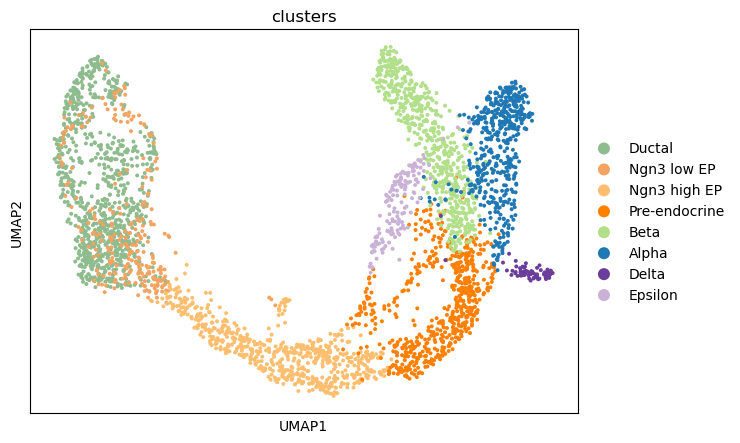

In [6]:
sc.pl.scatter(adata, basis="umap", color="clusters", frameon=True)

In [29]:
# 1. Define the mask (the condition)
mask = umap[:, 0] < umap[:, 0].mean()

# 2. Find the index within the original array that satisfies the mask AND has the max Y
# We use np.where to get the original indices of cells that passed the mask
passed_indices = np.where(mask)[0]
# Find which of those has the max Y value
sub_argmax = umap[mask, 1].argmax()
root_ixs = passed_indices[sub_argmax]

# sc.pl.scatter(adata_half, basis="umap", color="clusters")
# root_ixs = adata_half.obsm["X_umap"][:, 1].argmax()
print(root_ixs)
print(umap[root_ixs])
umap[:,0].mean()

1103
[-10.57519     6.3663063]


-1.0317537

In [31]:
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=50, use_rep='X_umap')
sc.tl.leiden(adata)
leiden = adata.obs["leiden"].to_numpy(dtype=int)

In [32]:
projected_points, mst, centroids = learn_graph(matrix=umap, clusters=leiden)

In [33]:
pseudotime = order_cells(
    umap, centroids,
    mst=mst,
    projected_points=projected_points,
    root_cells=[root_ixs],
)


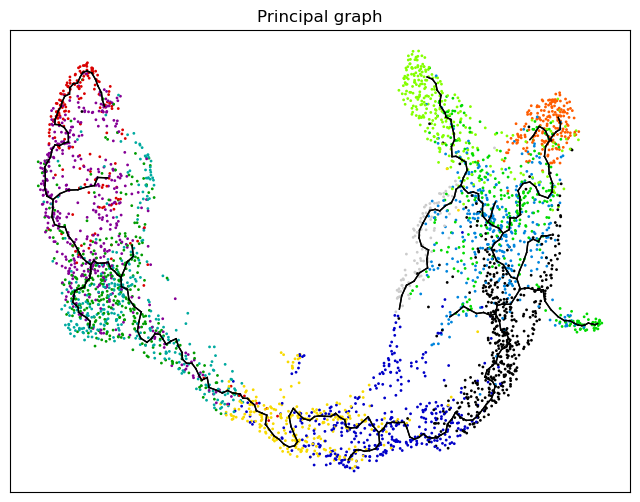

In [18]:
plt.figure(1, (8, 6))
plt.title("Principal graph")
plt.scatter(umap[:, 0], umap[:, 1], c=leiden, s=1, cmap="nipy_spectral")

edges = np.array(mst.nonzero()).T
for edge in edges:
    plt.plot(centroids[edge, 0], centroids[edge, 1], c="black", linewidth=1)
plt.xticks([])
plt.yticks([])
plt.show()

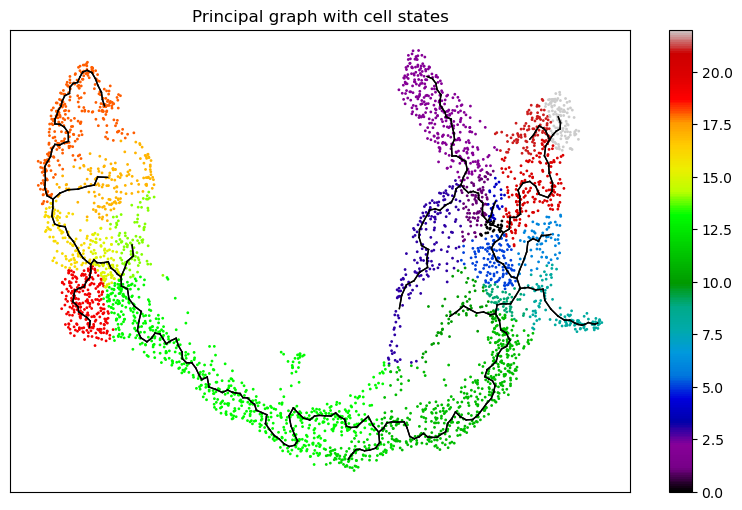

In [19]:
plt.figure(1, (10, 6))
plt.title("Principal graph with cell states")
cell_states, _ = compute_cell_states(umap, centroids, mst)
plt.scatter(umap[:, 0], umap[:, 1], c=cell_states, s=1, cmap="nipy_spectral")
plt.colorbar()
edges = np.array(mst.nonzero()).T
for edge in edges:
    plt.plot(centroids[edge, 0], centroids[edge, 1], c="black", linewidth=1)
plt.xticks([])
plt.yticks([])
plt.show()

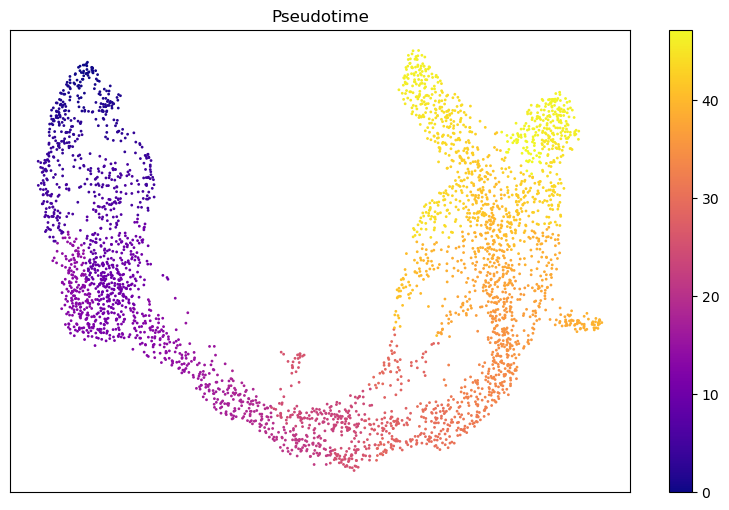

In [34]:
plt.figure(1, (10, 6))
plt.title("Pseudotime")
plt.scatter(umap[:, 0], umap[:, 1], c=pseudotime, s=1, cmap="plasma")
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

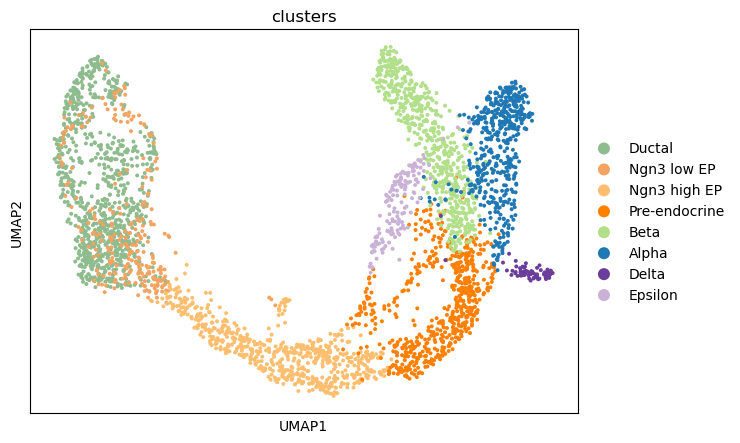